# Build Sol Dataset

## Install necessary libraries from python

In [ ]:
import os

src = "/kaggle/input/sc-vuldetection-dataset/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/TimestampDependencyDataset/Train/Vulnerable"

cnt = 0
for file in os.listdir(src):
    with open(src + "/" + file, "r") as f:
        data = f.read()
    if "block.timestamp" in data or "now" in data:
        cnt =+ 1

print(cnt)

In [1]:
# Use Gpu
!pip install dgl==2.0.0 -f https://data.dgl.ai/wheels/cu121/repo.html
# Only use cpu
# !pip install dgl==1.1.2

Looking in links: https://data.dgl.ai/wheels/cu121/repo.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.0/926.0 MB 1.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.3 MB/s eta 0:00:00


In [2]:
%%capture
# !apt install libgraphviz-dev
# !pip install pygraphviz
!pip install networkx
!pip install slither-analyzer

## Import Python libraries

In [3]:
from concurrent.futures import ThreadPoolExecutor
from random import sample
import json
import multiprocessing
import traceback
import pandas as pd
import os
from pathlib import Path
import networkx as nx
# import pygraphviz as pgv
import matplotlib.pyplot as plt
import nltk
import dgl
import os
import shutil
import random
from slither.slither import Slither
from typing import Tuple, Optional, Dict
from copy import deepcopy
from pathlib import Path
import glob
from multiprocessing import Pool as ThreadPool
from functools import partial
import torch.nn as nn
import torch
from torch import Tensor
import torch.nn.functional as F
from dgl.nn import GraphConv, GATConv, TAGConv, SAGEConv, GINConv, SumPooling, AvgPooling, MaxPooling, SortPooling, GlobalAttentionPooling, WeightAndSum, Set2Set, SetTransformerEncoder, SetTransformerDecoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import pickle
import random
import numpy as np
from tqdm import tqdm

DGL backend not selected or invalid.  Assuming PyTorch for now.


Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)


# Functions

In [4]:
def plot(x: list, y: list):
  x = np.array(x)
  y = np.array(y)

  plt.plot(x, y)
  plt.title("Decrease of loss over epochs")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.show()

In [5]:
def readData(path: str, n_nscam: int, n_scam: int):
  dic = {
      "filename": [],
      "label": []
  }
  cnt0, cnt1 = 0, 0
  for label in ["NonVulnerable_Fcg", "Vulnerable_Fcg"]:
    for file in sorted(os.listdir(path + "/" + label)):
      if file.endswith(".fcg"):
        if label == "NonVulnerable_Fcg":
          if cnt0 <= n_nscam:
            dic['filename'].append("/".join([path, label, file]))
            dic['label'].append(0)
            cnt0 += 1
        else:
          if cnt1 <= n_scam:
            dic['filename'].append("/".join([path, label, file]))
            dic['label'].append(1)
            cnt1 += 1
  df = pd.DataFrame(dic)
  return df

In [6]:
def loadfeatureGraph_5(path):
  """
    path: path to fcg file

    return: dgl.DGLGraph with feature size of 5
  """
  g = dgl.load_graphs(path)[0][0]
  return g

def loadfeatureGraph_100(path):
  """
    path: path to fcg file

    return: dgl.DGLGraph with feature size of 100
  """
  g = dgl.load_graphs(path)[0][0]
  g.ndata["features"] = g.ndata["featuresH"]
  return g

def loadfeatureGraph_105(path):
  """
    path: path to fcg file

    return: dgl.DGLGraph with feature size of 105
  """
  g = dgl.load_graphs(path)[0][0]
  template = g.ndata["features"]

  g.ndata["features"] = torch.cat([g.ndata["featuresH"], template], dim=1)
  return g

def createBatchMulThread_MultiOp(data, max_works, nfeatures):
  """
    data: Graph paths,
    nfeatures: Size of node feature
    max_works: number of thread use

    return list[DGLGraph]
  """
  pathfiles = data
  if nfeatures == 5:
    with ThreadPoolExecutor(max_works) as executor:
      graphs = list(executor.map(loadfeatureGraph_5, pathfiles))
  elif nfeatures == 768:
    with ThreadPoolExecutor(max_works) as executor:
      graphs = list(executor.map(loadfeatureGraph_100, pathfiles))
  elif nfeatures == 773:
    with ThreadPoolExecutor(max_works) as executor:
      graphs = list(executor.map(loadfeatureGraph_105, pathfiles))
  return graphs

# Model GNNs

In [43]:
import dgl.nn.pytorch as dglnn
import torch.nn as nn
from copy import deepcopy as dc

#---------------------------------------------------------------------------------------------------------------------
class MultiHeadCrossAttentionPooling(nn.Module):
    def __init__(self, hidden_dim, num_query_vectors=1, num_heads=4):
        super(MultiHeadCrossAttentionPooling, self).__init__()
        self.num_query_vectors = num_query_vectors
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        
        # Single set of query vectors, will be reshaped for multi-head
        self.query = nn.Parameter(torch.randn(num_query_vectors, hidden_dim))
        
        # Single transformations that will be reshaped for multi-head attention
        self.key_transform = nn.Linear(hidden_dim, hidden_dim)
        self.value_transform = nn.Linear(hidden_dim, hidden_dim)
        
        # Output projection
        self.output_projection = nn.Linear(hidden_dim, hidden_dim)
        
        # Final output dimension
        self.output_dim = hidden_dim * num_query_vectors
        
    def forward(self, g, h):
        graph_splits = g.batch_num_nodes()
        batch_size = len(graph_splits)
        device = h.device
        output = torch.zeros(batch_size, self.output_dim, device=device)
        
        # Transform once for all heads
        keys = self.key_transform(h)      # (total_nodes x hidden_dim)
        values = self.value_transform(h)   # (total_nodes x hidden_dim)
        
        # Reshape for multi-head attention
        # Reshape to: [num_nodes, num_heads, hidden_dim/num_heads]
        keys = keys.view(-1, self.num_heads, self.hidden_dim // self.num_heads)
        values = values.view(-1, self.num_heads, self.hidden_dim // self.num_heads)
        query = self.query.view(self.num_query_vectors, self.num_heads, -1)
        
        start_idx = 0
        for i, num_nodes in enumerate(graph_splits):
            end_idx = start_idx + num_nodes
            
            # Get current graph's nodes
            graph_keys = keys[start_idx:end_idx]    # (num_nodes x num_heads x head_dim)
            graph_values = values[start_idx:end_idx] # (num_nodes x num_heads x head_dim)
            
            # Calculate attention scores (for all heads simultaneously)
            scores = torch.matmul(query.permute(1, 0, 2), graph_keys.permute(1, 2, 0))
            # scores shape: [num_heads, num_queries, num_nodes]
            
            attention_weights = F.softmax(scores / (self.hidden_dim // self.num_heads) ** 0.5, dim=-1)
            
            # Apply attention
            head_outputs = torch.matmul(attention_weights, graph_values.permute(1, 0, 2))
            # head_outputs shape: [num_heads, num_queries, head_dim]
            
            # Concatenate heads and reshape
            multi_head_output = head_outputs.permute(1, 0, 2).reshape(self.num_query_vectors, -1)
            
            # Project output
            projected_output = self.output_projection(multi_head_output)
            
            # Store result
            output[i] = projected_output.reshape(-1)
            
            start_idx = end_idx
        
        return output
#---------------------------------------------------------------------------------------------------------------------

def get_convolution_layer(
            input_dimension: int,
            output_dimension: int,
            name: list,
            agg_hidden_dimension: int = 1024, # Only use for GINConv
            heads: int = 0 # Only use for GATConv
    ) -> Optional[nn.Module]:
        mlp, gin_agg, sage_agg = None, 'sum', 'mean'
        if name[0] == "GIN":
          mlp = nn.Sequential()
          mlp.append(nn.Linear(input_dimension, agg_hidden_dimension))
          mlp.append(nn.ReLU())
          mlp.append(nn.Linear(agg_hidden_dimension, output_dimension))
          gin_agg = name[1]

        if name[0] == "SAGE":
          sage_agg = name[1]

        return {"GCN": GraphConv(input_dimension, output_dimension, activation=F.relu),
                "SAGE": SAGEConv(input_dimension, output_dimension, activation=F.relu, norm=F.normalize, aggregator_type=sage_agg),
                "GAT": GATConv(input_dimension, output_dimension, num_heads=heads, activation=F.relu, feat_drop=0.0, attn_drop=0.0),
                "TAG": TAGConv(input_dimension, output_dimension, k=4, activation=F.relu),
                "GIN": GINConv(apply_func=mlp, activation=F.relu, aggregator_type=gin_agg)
                }.get(name[0], None)

def get_pooling_method(
            method_name: str,
            hidden_dim: int = None  # Add hidden_dim parameter
    ):
        return {"max": MaxPooling(),
                "mean": AvgPooling(),
                "sum": SumPooling(),
                "sort": SortPooling(k=3),
                "transformer": (SetTransformerEncoder(5, 4, 4, 20), SetTransformerDecoder(5, 4, 4, 20, 1, 3)),
                "global_attention": GlobalAttentionPooling(gate_nn=nn.Linear(hidden_dim, 1),
                                                         feat_nn=nn.Linear(hidden_dim, hidden_dim))
                }.get(method_name, None)

class GraphNN(nn.Module):
    def __init__(self, mtype, infeats, hfeats: list, fc1_layer, fc2_layer, outclass, gptype='max', ginfeat=None, num_query_vectors=1):
        super(GraphNN, self).__init__()
        self.mtype = mtype
        self.gptype = gptype
        self.hfeats = hfeats
        self.device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

        if mtype[0] == "GIN":
          self.conv1 = get_convolution_layer(input_dimension=infeats, output_dimension=hfeats[0],
                                             name=mtype, agg_hidden_dimension=ginfeat)
          if len(hfeats) >= 2:
            self.conv2 = get_convolution_layer(input_dimension=hfeats[0], output_dimension=hfeats[1],
                                               name=mtype, agg_hidden_dimension=ginfeat)
          if len(hfeats) >= 3:
            self.conv3 = get_convolution_layer(input_dimension=hfeats[1], output_dimension=hfeats[2],
                                               name=mtype, agg_hidden_dimension=ginfeat)
        else:
          if mtype != ["GAT"]:
            self.conv1 = get_convolution_layer(input_dimension=infeats, output_dimension=hfeats[0], name=mtype)
            if len(hfeats) >= 2:
                self.conv2 = get_convolution_layer(input_dimension=hfeats[0], output_dimension=hfeats[1], name=mtype)
            if len(hfeats) >= 3:
                self.conv3 = get_convolution_layer(input_dimension=hfeats[1], output_dimension=hfeats[2], name=mtype)
          else:
            if len(hfeats) > 1:
              self.conv1 = get_convolution_layer(input_dimension=infeats, output_dimension=hfeats[0], name=mtype, heads=8)
            elif len(hfeats) == 1:
              self.conv1 = get_convolution_layer(input_dimension=infeats, output_dimension=hfeats[0], name=mtype, heads=1)
            if len(hfeats) > 2:
              self.conv2 = get_convolution_layer(input_dimension=(hfeats[0] * 8), output_dimension=(hfeats[1] * 8), name=mtype, heads=8)
            elif len(hfeats) == 2:
              self.conv2 = get_convolution_layer(input_dimension=(hfeats[0] * 8), output_dimension=hfeats[1], name=mtype, heads=1)
            if len(hfeats) == 3:
              self.conv3 = get_convolution_layer(input_dimension=(hfeats[1] * 8), output_dimension=hfeats[2], name=mtype, heads=1)

        # In GraphNN's __init__
        if gptype == 'cross_attention':
            self.pooling = MultiHeadCrossAttentionPooling(hidden_dim=hfeats[-1], num_query_vectors=num_query_vectors)
            fc1_input_dim = hfeats[-1] * num_query_vectors
        else:
            self.pooling = get_pooling_method(gptype, hidden_dim=hfeats[-1])  # Pass the hidden dimension
            fc1_input_dim = hfeats[-1]

        # Adjust FC layers for concatenated output
        self.fc1 = nn.Linear(fc1_input_dim, fc1_layer)
        self.fc2 = nn.Linear(fc1_layer, fc2_layer)
        self.fc3 = nn.Linear(fc2_layer, outclass)

        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.xavier_uniform_(self.fc3.weight)

    def forward(self, g, infeats):
        # Apply graph convolution and activation.
        h = self.conv1(g, infeats)
        if self.mtype == ["GAT"]: h = h.reshape(h.shape[0], -1)
        if len(self.hfeats) >= 2:
          h = self.conv2(g, h)
          if self.mtype == ["GAT"]: h = h.reshape(h.shape[0], -1)
        if len(self.hfeats) >= 3:
          h = self.conv3(g, h)
          if self.mtype == ["GAT"]: h = h.reshape(h.shape[0], -1)
        # with g.local_scope():

        g.ndata['features'] = h
        if self.gptype == "cross_attention":
            h = self.pooling(g, g.ndata['features'])
        elif self.gptype == "transformer":
            enc_nodes, dec_nodes = get_pooling_method(self.gptype)
            h = enc_nodes(g, g.ndata['features'])
            h = dec_nodes(g, g.ndata['features'])
        else:
            h = self.pooling(g, g.ndata['features'])

        ans = self.fc1(h)
        ans = F.relu(ans)
        ans = self.fc2(ans)
        ans = F.relu(ans)
        return self.fc3(ans)

    def save(self, path):
      torch.save(self.state_dict(), path)

    def load(self, path):
      self.load_state_dict(torch.load(path))

# Training

In [16]:
from dgl.data import DGLDataset
from dgl.dataloading import GraphDataLoader

class GraphDataset(DGLDataset):
    def __init__(self, graphs, labels):
        super().__init__(name='graph_dataset')
        self.graphs = graphs
        self.labels = labels
    def process(self):
        # Here, you could preprocess the data if needed.
        pass

    def __getitem__(self, idx):
        return self.graphs[idx], self.labels[idx]

    def __len__(self):
        return len(self.graphs)

In [45]:
def train_and_eval(dataloader, tdataloader, mtype, s_epoch, e_epoch, n_workers, n_feats, hfeats, gptype, ginfeat, num_query_vectors):
    model = GraphNN(mtype=mtype, infeats=n_feats, hfeats=hfeats, fc1_layer=256, fc2_layer=64, outclass=2, gptype=gptype, ginfeat=ginfeat)
    model.to(model.device)
    print(model)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
    criterion = torch.nn.CrossEntropyLoss()

    result = {
        "data": os.path.basename(data_path),
        "loss":[],
        "val_acc": [],
        "val_f1": [],
        "epoch": []
    }

    for epoch in (range(s_epoch, e_epoch)):
        bloss, bpred, blabel = [], [], []
        for batched_graph, label_batch in tqdm(dataloader):
            batched_graph, label_batch = batched_graph.to(model.device), label_batch.to(model.device)
            feats = batched_graph.ndata['features']
            model.train()
            pred_batch = model(batched_graph, feats)
            loss = criterion(pred_batch, label_batch)
            out_batch = pred_batch.argmax(dim=1).long()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            bloss.append(loss.item())
            bpred.extend(out_batch.tolist())
            blabel.extend(label_batch.tolist())


        result['loss'].append(sum(bloss)/len(bloss))
        result['epoch'].append(epoch)
        print("Epoch:", epoch, "   Loss:", sum(bloss)/len(bloss),f"   Accuracy: {(accuracy_score(bpred, blabel)* 100):.4f}%")
        # if os.path.exists(f"/content/drive/MyDrive/ScamSolidityCodeDetection/ModelWeights/{mtype[0]}_{mtype[1]}_{len(hfeats)}_{gptype}_f{n_feats}") == False:
        #     os.mkdir(f"/content/drive/MyDrive/ScamSolidityCodeDetection/ModelWeights/{mtype[0]}_{mtype[1]}_{len(hfeats)}_{gptype}_f{n_feats}")
        # model.save(f"/content/drive/MyDrive/ScamSolidityCodeDetection/ModelWeights/{mtype[0]}_{mtype[1]}_{len(hfeats)}_{gptype}_f{n_feats}/model_{os.path.basename(data_path)}_{str(epoch).zfill(2)}.pt")
        model.eval()
        with torch.no_grad():
            tpred, tlabel = [], []
            for tbatched_graph, tlabels in (tdataloader):
                tbatched_graph, tlabels = tbatched_graph.to(model.device), tlabels.to(model.device)
                tfeats = tbatched_graph.ndata['features']
                out = model(tbatched_graph, tfeats)
                preds = out.argmax(dim=1).long()
                tpred.extend(preds.tolist())
                tlabel.extend(tlabels.tolist())

            print(f'Val Accuracy: {(accuracy_score(tlabel, tpred) * 100):.2f}%')
            print(f'Val F1 Score: {(f1_score(np.array(tlabel), np.array(tpred)) * 100):.2f}%')
            print(f'Val Precision: {(precision_score(tlabel, tpred) * 100):.2f}%')
            print(f'Val Recall: {(recall_score(tlabel, tpred) * 100):.2f}%')
            result['val_acc'].append(accuracy_score(tlabel, tpred))
            result['val_f1'].append(f1_score(np.array(tlabel), np.array(tpred)))

    plot(result["epoch"], result["loss"])
    return result

In [36]:
import random

random.seed(42)

data_path = "/kaggle/input/sol2graphconverter/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/ReentrancyDataset"

train_df = readData(f"{data_path}/Train", 2047, 2047)
train_df = train_df.sample(frac=1).reset_index(drop=True)

test_df = readData(f"{data_path}/Test", 2047, 2047)
test_df = test_df.sample(frac=1).reset_index(drop=True)

display(train_df.head())
display(test_df.head())

print(f"Train Dataset size: {len(train_df)} files")
print(f"Test Dataset size: {len(test_df)} files")

X_train, y_train = train_df.drop(['label'], axis=1), train_df['label']
X_test, y_test = test_df.drop(['label'], axis=1), test_df['label']
# X_train, X_test, y_train, y_test = train_test_split(df.drop(['label'], axis=1), df['label'], test_size=0.2, random_state=42)

graphs = createBatchMulThread_MultiOp(X_train['filename'].tolist(), 16, 773)
graphs = [dgl.add_self_loop(g) for g in graphs]
dataset = GraphDataset(graphs, Tensor(list(y_train)).long())
dataloader = GraphDataLoader(
    dataset,
    batch_size=128,
    drop_last=False,
    shuffle=True)

tgraphs = createBatchMulThread_MultiOp(X_test['filename'].tolist(), 16, 773)
tgraphs = [dgl.add_self_loop(g) for g in tgraphs]
tdataset = GraphDataset(tgraphs, Tensor(list(y_test)).long())
tdataloader = GraphDataLoader(
    tdataset,
    batch_size=512,
    drop_last=False,
    shuffle=True)

,filename,label
0,/kaggle/input/sol2graphconverter/SmartContract...,1
1,/kaggle/input/sol2graphconverter/SmartContract...,0
2,/kaggle/input/sol2graphconverter/SmartContract...,0
3,/kaggle/input/sol2graphconverter/SmartContract...,0
4,/kaggle/input/sol2graphconverter/SmartContract...,1


,filename,label
0,/kaggle/input/sol2graphconverter/SmartContract...,0
1,/kaggle/input/sol2graphconverter/SmartContract...,1
2,/kaggle/input/sol2graphconverter/SmartContract...,1
3,/kaggle/input/sol2graphconverter/SmartContract...,0
4,/kaggle/input/sol2graphconverter/SmartContract...,0


Train Dataset size: 500 files
Test Dataset size: 121 files


In [11]:
print(len(os.listdir("/kaggle/input/sc-vuldetection-dataset/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/ReentrancyDataset/Test/NonVulnerable")))
print(len(os.listdir("/kaggle/input/sc-vuldetection-dataset/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/ReentrancyDataset/Test/Vulnerable")))

74
73


In [12]:
print(len(os.listdir("/kaggle/input/sc-vuldetection-dataset/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/ReentrancyDataset/Train/NonVulnerable")))
print(len(os.listdir("/kaggle/input/sc-vuldetection-dataset/SmartContractVulnerabilityDetection/SourceCodeSyntaxDataset/ReentrancyDataset/Train/Vulnerable")))

298
297


In [31]:
print(len(train_df[train_df['label'] == 0]), len(train_df[train_df['label'] == 1]))
print(len(test_df[test_df['label'] == 0]), len(test_df[test_df['label'] == 1]))

249 252
49 62


GraphNN(
  (conv1): GATConv(
    (fc): Linear(in_features=773, out_features=8192, bias=False)
    (feat_drop): Dropout(p=0.0, inplace=False)
    (attn_drop): Dropout(p=0.0, inplace=False)
    (leaky_relu): LeakyReLU(negative_slope=0.2)
  )
  (conv2): GATConv(
    (fc): Linear(in_features=8192, out_features=512, bias=False)
    (feat_drop): Dropout(p=0.0, inplace=False)
    (attn_drop): Dropout(p=0.0, inplace=False)
    (leaky_relu): LeakyReLU(negative_slope=0.2)
  )
  (pooling): MultiHeadCrossAttentionPooling(
    (key_transform): Linear(in_features=512, out_features=512, bias=True)
    (value_transform): Linear(in_features=512, out_features=512, bias=True)
    (output_projection): Linear(in_features=512, out_features=512, bias=True)
  )
  (fc1): Linear(in_features=512, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
)


100%|██████████| 4/4 [00:00<00:00,  4.02it/s]


Epoch: 0    Loss: 0.9526879787445068    Accuracy: 46.0000%
Val Accuracy: 51.24%
Val F1 Score: 67.76%
Val Precision: 51.24%
Val Recall: 100.00%


100%|██████████| 4/4 [00:00<00:00,  4.15it/s]


Epoch: 1    Loss: 0.5948734283447266    Accuracy: 68.0000%
Val Accuracy: 69.42%
Val F1 Score: 75.82%
Val Precision: 63.74%
Val Recall: 93.55%


...

Epoch: 97    Loss: 0.039774559903889894    Accuracy: 97.8000%
Val Accuracy: 84.30%
Val F1 Score: 85.71%
Val Precision: 80.28%
Val Recall: 91.94%


100%|██████████| 4/4 [00:00<00:00,  4.18it/s]


Epoch: 98    Loss: 0.047028171829879284    Accuracy: 97.6000%
Val Accuracy: 82.64%
Val F1 Score: 84.44%
Val Precision: 78.08%
Val Recall: 91.94%


100%|██████████| 4/4 [00:00<00:00,  4.04it/s]


Epoch: 99    Loss: 0.07123377826064825    Accuracy: 96.8000%
Val Accuracy: 82.64%
Val F1 Score: 84.44%
Val Precision: 78.08%
Val Recall: 91.94%


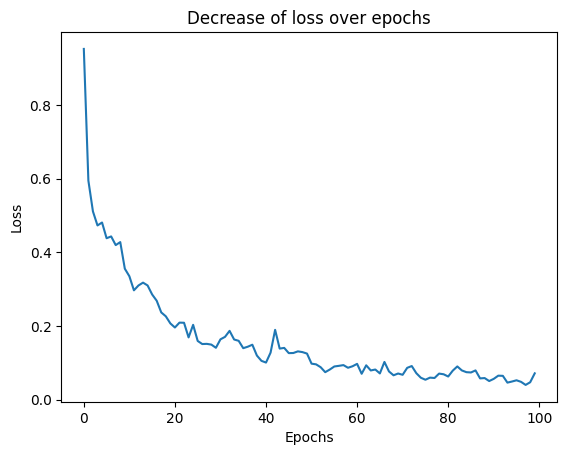

In [49]:
# GCN, SAGE, GAT, TAG, GIN
# layer 1, 2, 3
# 128
# 256, 128
# 256, 256, 128

n_feats = 773
n_batch=128

# result_dict = {}
# for mtype in [['GAT'], ['SAGE', 'pool'], ['SAGE', 'mean'], ['SAGE', 'lstm'], ['GCN'], ['TAG'], ['GIN', 'max'], ['GIN', 'sum'], ['GIN', 'mean']]:
#     for hfeats in [[128], [256, 128], [256, 256, 128]]:
#         for gptype in ['sum', 'mean', 'max']:
#             print(mtype, hfeats, gptype)
#             tmp = train_and_eval(dataloader=dataloader, tdataloader=tdataloader, mtype=mtype,
#                                         s_epoch=0, e_epoch=500, n_workers=64, n_feats=n_feats,
#                                         hfeats=hfeats, gptype=gptype, ginfeat=1024)
#             res = [(i, j) for i, j in zip(tmp['val_f1'], tmp['val_acc'])]
#             print(max(res))
#             result_dict[f"{mtype}_{hfeats}_{gptype}"] = tmp

result = train_and_eval(dataloader=dataloader, tdataloader=tdataloader, mtype=['GAT'],
                                        s_epoch=0, e_epoch=100, n_workers=64, n_feats=n_feats,
                                        hfeats=[1024, 512], gptype='cross_attention', ginfeat=1024, num_query_vectors=2)

In [50]:
res = [(i, j) for i, j in zip(result['val_f1'], result['val_acc'])]
print(max(res))

(0.8907563025210085, 0.8925619834710744)


In [ ]:
# import json

# line_list = [EFcgDataset]
# name_list = ['EFcgDataset']

# for i in range(len(line_list)):
#   with open(f"/content/drive/MyDrive/ScamSolidityCodeDetection/plots/{name_list[i]}_{mtype}_{len(hfeats)}.json", "w") as outfile:
#       json.dump(line_list[i], outfile)

In [ ]:
# # importing package
# import matplotlib.pyplot as plt
# import numpy as np
# from scipy.interpolate import make_interp_spline

# def ploting(line_list, name_list, line_type):
#   epoches = range(350)
#   plt.figure(figsize=(10, 10))
#   for i in range(len(line_list)):
#     # plot lines
#     X_Y_Spline = make_interp_spline(epoches, line_list[i][line_type])
#     X_ = np.linspace(min(epoches), max(epoches), 50000)
#     Y_ = X_Y_Spline(X_)

#     plt.plot(X_, Y_, label = name_list[i])
#   plt.legend()
#   plt.show()

# ploting([EFcgDataset], ['EFcgDataset - GAT - 2'], 'val_f1')

In [ ]:
# # (0.852112676056338, 0.8775510204081632)
# res = [(i, j) for i, j in zip(EFcgDataset['val_f1'], EFcgDataset['val_acc'])]

# print(max(res))

# Checking

In [ ]:
# !mkdir  /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedNonScam
# !mkdir  /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedScam

In [ ]:
# # !zip -r /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedNonScam/EFcgDataset_NonScam.zip /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/NonScam
# !zip -r /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedScam/EFcgDataset_Scam.zip /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/Scam

In [ ]:
# import os
# import json
# # quangnguyen11037 benign (1 - 13)
# # quangnguyen2910 benign (14 - 25)
# # quangnm711 malware (full)

# dictionary = {
#   "title": f"Sol_Dataset_EFcg_NonScam",
#   "id": f"quangnguyen11037/sol-dataset-efcg-nonscam",
#   "licenses": [
#     {
#       "name": "CC0-1.0"
#     }
#   ]
# }

# # Serializing json
# json_object = json.dumps(dictionary, indent=2)

# # Writing to sample.json
# with open(f"/content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedNonScam/dataset-metadata.json", "w") as outfile:
#     outfile.write(json_object)

# dictionary = {
#   "title": f"Sol_Dataset_EFcg_Scam",
#   "id": f"quangnguyen11037/sol-dataset-efcg-scam",
#   "licenses": [
#     {
#       "name": "CC0-1.0"
#     }
#   ]
# }

# # Serializing json
# json_object = json.dumps(dictionary, indent=2)

# # Writing to sample.json
# with open(f"/content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedScam/dataset-metadata.json", "w") as outfile:
#     outfile.write(json_object)

In [ ]:
# os.environ['KAGGLE_CONFIG_DIR'] = "/content/quangnguyen11037"

In [ ]:
# !chmod 600 /content/quangnguyen11037/kaggle.json

In [ ]:
# !kaggle datasets create -p /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedNonScam --dir-mode skip --public
# !kaggle datasets create -p /content/drive/MyDrive/ScamSolidityCodeDetection/EFcgDataset/ZippedScam --dir-mode skip --public